## Install and import

In [2]:

# %pip install ultralytics opencv-python matplotlib
# 'ultralytics' also pulls in PyTorch automatically


## Our imports — and why we need each one

In [3]:
from ultralytics import YOLO   # the YOLO model (load + run)
import cv2                     # OpenCV: read & draw rectangles and text
import matplotlib.pyplot as plt # display images inside the notebook
import numpy as np             # arrays / small numeric helpers

# Show matplotlib figures directly under each cell
%matplotlib inline

# Nicer default figure size for teaching
plt.rcParams["figure.figsize"] = (10, 7)

print("🟩 Imports OK")
print("OpenCV version   :", cv2.__version__)


🟩 Imports OK
OpenCV version   : 5.0.0


## Helper function

In [4]:
def show(image_bgr, title="", figsize=(10, 7)):
    """Display an OpenCV (BGR) image inside the notebook."""
    
    # Parameters
    # image_bgr : ndarray -> image in OpenCV's BGR channel order
    # title     : str     -> title printed above the image
    
    plt.figure(figsize=figsize)
    # BGR -> RGB, otherwise colours are wrong in matplotlib
    plt.imshow(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB))
    plt.title(title, fontsize=13, fontweight="bold")
    plt.axis("off")      # pixel axes are noisy / useless here
    plt.tight_layout()
    plt.show()

print("🟩 Helper `show()` ready")


🟩 Helper `show()` ready


## 3 · Load a pretrained YOLO model

In [5]:
model = YOLO("yolo26n.pt")

print("🟩 Pretrained YOLO model loaded")


🟩 Pretrained YOLO model loaded


What does this model actually know?

A detection model can only find classes it was trained on. Let's look at that list — it is stored in `model.names`, a dictionary `{class_id: class_name}`

In [6]:
# model.names maps a numeric class ID -> a human-readable name
class_names = model.names

print(f"The model knows {len(class_names)} classes.\n")

# Peek at the first few IDs
for class_id in range(5):
    print(f" ID {class_id:2d} -> {class_names[class_id]}")

print(f"\nAll 80 classes:")
print("-" * 68)
# Print them in a tidy grid so students can scan the list
all_names = [class_names[i] for i in range(len(class_names))]
for row_start in range(0, len(all_names), 5):
    print("   ".join(f"{n:<16}" for n in all_names[row_start:row_start + 5]))


The model knows 80 classes.

 ID  0 -> person
 ID  1 -> bicycle
 ID  2 -> car
 ID  3 -> motorcycle
 ID  4 -> airplane

All 80 classes:
--------------------------------------------------------------------
person             bicycle            car                motorcycle         airplane        
bus                train              truck              boat               traffic light   
fire hydrant       stop sign          parking meter      bench              bird            
cat                dog                horse              sheep              cow             
elephant           bear               zebra              giraffe            backpack        
umbrella           handbag            tie                suitcase           frisbee         
skis               snowboard          sports ball        kite               baseball bat    
baseball glove     skateboard         surfboard          tennis racket      bottle          
wine glass         cup                fork          

## 4 · Load and display our image

Look at that list. Notice what is there (person, dog, bicycle, laptop, bottle...) and what is not (your face, a specific brand, a tumor) — that is what you would have to train or fine-tune — that is a later session.

Loaded : data/dog.jpg
Shape  : (576, 768, 3) -> height=576, width=768, channels=3
Type   : ndarray, dtype=uint8


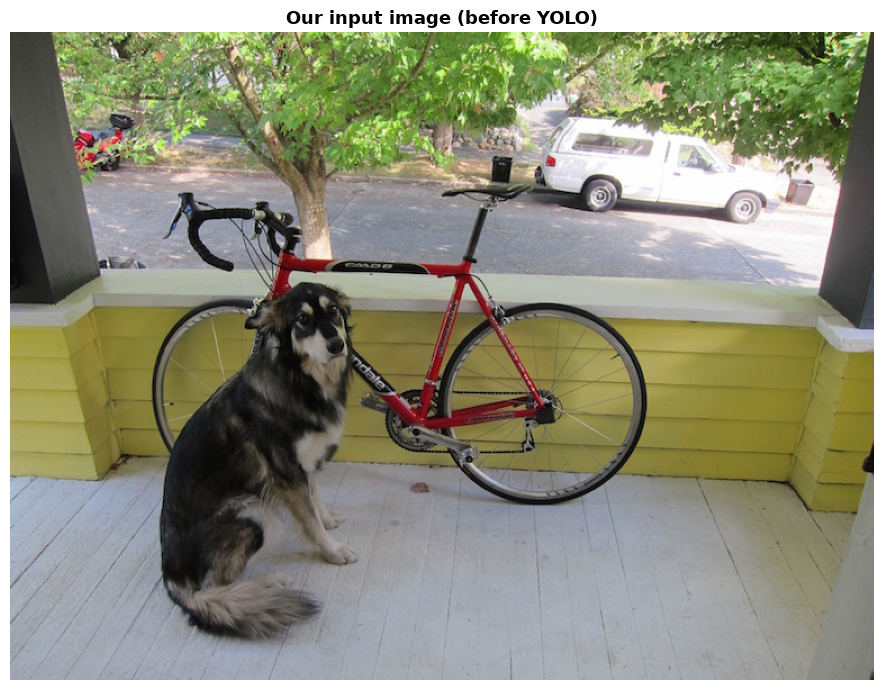

In [7]:
IMAGE_PATH = "data/dog.jpg"

# cv2.imread returns a NumPy array of shape (height, width, 3) in BGR order
image = cv2.imread(IMAGE_PATH)

# Always check the load succeeded - imread returns None on a bad path
if image is None:
    raise FileNotFoundError(f"Could not read '{IMAGE_PATH}'. Is it inside the 'data' folder?")

height, width, channels = image.shape
print(f"Loaded : {IMAGE_PATH}")
print(f"Shape  : {image.shape} -> height={height}, width={width}, channels={channels}")
print(f"Type   : {type(image).__name__}, dtype={image.dtype}")

show(image, "Our input image (before YOLO)")

## 5 · Run YOLO inference

This is the entire "run the AI model" step. One line:
`results = model(image)`

That is it. No preprocessing, no resizing, no normalising — Ultralytics does all of that for us internally.

In [8]:
# Run the model on our image.
# `verbose=False` just hides Ultralytics' own console log so the output is clean.
results = model(image, verbose=False)

print("Inference done 🟩")
print("Type of `results` :", type(results))
print("Length of `results`:", len(results))

Inference done 🟩
Type of `results` : <class 'list'>
Length of `results`: 1


Why is results a list?

Because YOLO can process a batch of images in one call. We passed one image, so we get a list with one result object in it.
`model([img1, img2, img3]) -> [Results, Results, Results]`
`model(img1)               -> [Results]                 * our case`

So we grab the first (and only) element:

In [9]:
# One image in -> one Results object out
result = results[0]

# Printing the whole object dumps a LOT - it even contains the raw pixels.
# So we look at just the first few lines of it:
print(str(result)[:430])
print(" ... (truncated)")


ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
depth: None
keypoints: None
masks: None
names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow',
 ... (truncated)


That printout is dense — that is fine. The important message is:

`result` is a structured object, not a picture. It holds the raw numbers YOLO predicted. Drawing them on the image is...

Let's see what is inside it.

In [10]:
# The interesting attributes on a Results object
print("result.boxes       ->", type(result.boxes), " (all the detections)")
print("result.names       ->", type(result.names), " (id -> class name map)")
print("result.orig_shape  ->", type(result.orig_shape), " (original image height, width)")
print("result.speed       ->", type(result.speed), " (time per stage)")


result.boxes       -> <class 'ultralytics.engine.results.Boxes'>  (all the detections)
result.names       -> <class 'dict'>  (id -> class name map)
result.orig_shape  -> <class 'tuple'>  (original image height, width)
result.speed       -> <class 'dict'>  (time per stage)


## 6 · Explore the detection results

In [11]:
boxes = result.boxes

print("How many objects did YOLO detect? ->", len(boxes))
print()
print(boxes)

How many objects did YOLO detect? -> 4

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([ 1., 16.,  7.,  2.])
conf: tensor([0.9309, 0.8962, 0.6892, 0.3795])
data: tensor([[1.2476e+02, 1.3455e+02, 5.6848e+02, 4.2250e+02, 9.3088e-01, 1.0000e+00],
        [1.3141e+02, 2.2149e+02, 3.1103e+02, 5.4241e+02, 8.9625e-01, 1.6000e+01],
        [4.6735e+02, 7.4343e+01, 6.9072e+02, 1.7263e+02, 6.8919e-01, 7.0000e+00],
        [4.6583e+02, 7.4961e+01, 6.9020e+02, 1.7191e+02, 3.7949e-01, 2.0000e+00]])
id: None
is_track: False
orig_shape: (576, 768)
shape: torch.Size([4, 6])
xywh: tensor([[346.6184, 278.5269, 443.7177, 287.9450],
        [221.2206, 381.9491, 179.6201, 320.9257],
        [579.0353, 123.4877, 223.3707,  98.2896],
        [578.0162, 123.4342, 224.3735,  96.9455]])
xywhn: tensor([[0.4513, 0.4836, 0.5778, 0.4999],
        [0.2880, 0.6631, 0.2339, 0.5572],
        [0.7540, 0.2144, 0.2908, 0.1706],
        [0.7526, 0.2143, 0.2922, 0.1683]])
xyxy: tensor([[124.7595, 134.

The three arrays you will use 99 % of the time

| Attribute | Shape | Meaning |
| :--- | :--- | :--- |
| `boxes.xyxy` | `(N, 4)` | the box corners: x1, y1, x2, y2 in pixels |
| `boxes.conf` | `(N,)` | the confidence of each detection, 0.0 - 1.0 |
| `boxes.cls` | `(N,)` | the class ID of each detection (a float, e.g. 15.0) |

where N = number of detected objects.

Each row i of these arrays describes the same object:

```text
          xyxy[0]          conf[0]     cls[0]
[131, 219, 309, 541]    0.91        16.0  <- object #0
[126, 126, 570, 421]    0.89        1.0   <- object #1
...

In [12]:
# — The bounding boxes
print("result.boxes.xyxy  (x1, y1, x2, y2 in pixels)")
print(result.boxes.xyxy)
print("shape:", tuple(result.boxes.xyxy.shape), "\n")


result.boxes.xyxy  (x1, y1, x2, y2 in pixels)
tensor([[124.7595, 134.5544, 568.4772, 422.4995],
        [131.4105, 221.4863, 311.0306, 542.4119],
        [467.3499,  74.3429, 690.7206, 172.6325],
        [465.8295,  74.9614, 690.2029, 171.9069]])
shape: (4, 4) 



In [13]:
# — The confidence scores
print("result.boxes.conf  (0.0 = no idea, 1.0 = totally sure)")
print(result.boxes.conf)
print("shape:", tuple(result.boxes.conf.shape), "\n")


result.boxes.conf  (0.0 = no idea, 1.0 = totally sure)
tensor([0.9309, 0.8962, 0.6892, 0.3795])
shape: (4,) 



In [14]:
# — The class IDs
print("result.boxes.cls  (numeric class IDs, stored as floats)")
print(result.boxes.cls)
print("shape:", tuple(result.boxes.cls.shape), "\n")

# IDs are meaningless on their own - we look them up in the names dictionary
print("Translating the IDs into names:")
for class_id in result.boxes.cls:
    cid = int(class_id)                       # 16.0 -> 16
    print(f"  class ID {cid:>3} -> '{result.names[cid]}'")


result.boxes.cls  (numeric class IDs, stored as floats)
tensor([ 1., 16.,  7.,  2.])
shape: (4,) 

Translating the IDs into names:
  class ID   1 -> 'bicycle'
  class ID  16 -> 'dog'
  class ID   7 -> 'truck'
  class ID   2 -> 'car'


## Reading a bounding box

YOLO gives box coordinates in the xyxy format:
- `(x1, y1)` -> top-left corner, in pixels
- `(x2, y2)` -> bottom-right corner, in pixels
- therefore `width = x2 - x1` and `height = y2 - y1`

These are pixel coordinates in the original image, so you can use them directly with OpenCV — which is exactly what we will do in section 9.

Ultralytics also offers `boxes.xywh` (centre-x, centre-y, width, height) and `boxes.xyxy` (the same corners but normalised to 0-1). We stick with `xyxy` because it plugs straight into `cv2.rectangle()`.

In [15]:
# Proof that the formats describe the same rectangle, for object #0
xyxy = result.boxes.xyxy[0].tolist()
xywh = result.boxes.xywh[0].tolist()

print(f"xyxy : x1={xyxy[0]:.0f}, y1={xyxy[1]:.0f}, x2={xyxy[2]:.0f}, y2={xyxy[3]:.0f}")
print(f"xywh : cx={xywh[0]:.0f}, cy={xywh[1]:.0f}, w={xywh[2]:.0f}, h={xywh[3]:.0f}")
print()
print(f"Computed from xyxy -> width = x2 - x1 = {xyxy[2] - xyxy[0]:.0f}")
print(f"               height = y2 - y1 = {xyxy[3] - xyxy[1]:.0f}")


xyxy : x1=125, y1=135, x2=568, y2=422
xywh : cx=347, cy=279, w=444, h=288

Computed from xyxy -> width = x2 - x1 = 444
               height = y2 - y1 = 288


## 7 · Extract ONE detection manually


In [16]:
# Take the very first detection
box        = result.boxes.xyxy[0]     # tensor(([x1, y1, x2, y2]))
confidence = result.boxes.conf[0]     # tensor(0.91)
class_id   = result.boxes.cls[0]      # tensor(16.)

# These are PyTorch tensors - convert them to plain Python numbers
x1, y1, x2, y2 = [int(v) for v in box]  # pixels must be ints for OpenCV
confidence     = float(confidence)
class_id       = int(class_id)
class_name     = result.names[class_id]  # look the ID up in the names dict

print("-" * 46)
print("               DETECTION #0")
print("-" * 46)
print(f"Bounding box : x1={x1}, y1={y1}, x2={x2}, y2={y2}")
print(f"Box size     : {x2 - x1} px wide x {y2 - y1} px tall")
print(f"Confidence   : {confidence:.4f}  -> {confidence * 100:.1f} %")
print(f"Class ID     : {class_id}")
print(f"Class name   : '{class_name}'")
print("-" * 46)


----------------------------------------------
               DETECTION #0
----------------------------------------------
Bounding box : x1=124, y1=134, x2=568, y2=422
Box size     : 444 px wide x 288 px tall
Confidence   : 0.9309  -> 93.1 %
Class ID     : 1
Class name   : 'bicycle'
----------------------------------------------


## Let's actually see that one box

To prove those 4 numbers really are a rectangle in the image, we simply crop the image with them using NumPy slicing 

Cropped region shape: (288, 444, 3)


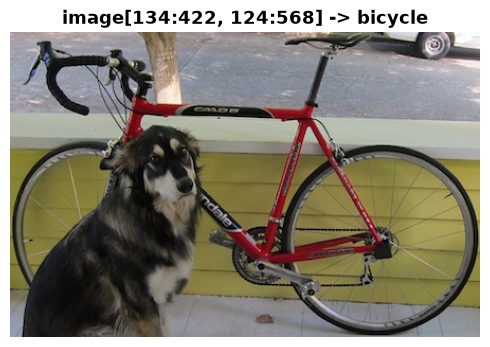

In [17]:
# NumPy slicing order is [y_start:y_end, x_start:x_end]
crop = image[y1:y2, x1:x2]

print(f"Cropped region shape: {crop.shape}")
show(crop, f"image[{y1}:{y2}, {x1}:{x2}] -> {class_name}", figsize=(5, 5))


## 8 · Understanding confidence scores 

The confidence score represents how confident the model is that a detected object belongs to the predicted class.
It always sits between 0.0 and 1.0, and we show it to humans as a percentage

Print every detection with a clean loop

Now we combine everything: loop over the detections and print class + confidence + box for each one.

In [18]:
print(f"YOLO found {len(result.boxes)} objects\n")
print(f"{'#':<3}{'CLASS':<14}{'CONFIDENCE':<14}{'BOUNDING BOX (x1, y1, x2, y2)'}")
print("-" * 74)

# Iterating over result.boxes gives us one Box at a time
for i, box in enumerate(result.boxes):
    # Every attribute is a 1-element tensor for a single box -> take [0]
    x1, y1, x2, y2 = [int(v) for v in box.xyxy[0]]
    confidence     = float(box.conf[0])
    class_id       = int(box.cls[0])
    class_name     = result.names[class_id]

    print(f"{i:<3}{class_name:<14}{confidence:.2f}  ({confidence*100:4.1f}%) "
          f"({x1}, {y1}, {x2}, {y2})")

print("-" * 74)

YOLO found 4 objects

#  CLASS         CONFIDENCE    BOUNDING BOX (x1, y1, x2, y2)
--------------------------------------------------------------------------
0  bicycle       0.93  (93.1%) (124, 134, 568, 422)
1  dog           0.90  (89.6%) (131, 221, 311, 542)
2  truck         0.69  (68.9%) (467, 74, 690, 172)
3  car           0.38  (37.9%) (465, 74, 690, 171)
--------------------------------------------------------------------------



Numbers are abstract — a bar makes the difference obvious.

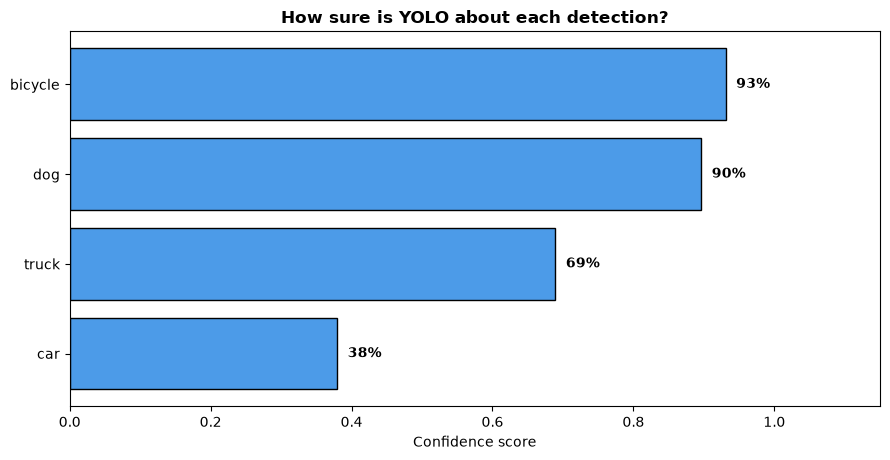

In [19]:
# Collect labels and scores for plotting
labels = [f"{result.names[int(b.cls[0])]}" for b in result.boxes]
scores = [float(b.conf[0]) for b in result.boxes]

# Sort from most to least confident so the chart reads top-down
order = np.argsort(scores)
labels = [labels[i] for i in order]
scores = [scores[i] for i in order]

plt.figure(figsize=(9, 0.8 * len(labels) + 1.5))
bars = plt.barh(labels, scores, color="#4C9BE8", edgecolor="black")

# Write the percentage at the end of each bar
for bar, s in zip(bars, scores):
    plt.text(s + 0.015, bar.get_y() + bar.get_height() / 2,
             f"{s*100:.0f}%", va="center", fontweight="bold")

plt.xlim(0, 1.15)
plt.xlabel("Confidence score")
plt.title("How sure is YOLO about each detection?", fontweight="bold")
plt.tight_layout()
plt.show()


## 9 · Draw the bounding boxes manually 

This section exists so that you never think of the boxes as magic.

> A bounding box is just a rectangle drawn from 4 numbers the model predicted. Nothing more.
> 
> **YOLO prediction**  
> │  
> ▼  
> `[x1, y1, x2, y2]`  
> │  
> ▼  
> `cv2.rectangle()`  
> │  
> ▼  
> **Bounding box on screen**

### The two OpenCV functions we need

```python
cv2.rectangle(img, (x1, y1), (x2, y2), color, thickness)
cv2.putText(img, text, (x, y), font, scale, color, thickness)

Remember colours in OpenCV are (B, G, R), so pure red is (0, 0, 255).

Step 1 — draw a single box, slowly
Before the loop, let's draw just one rectangle so every argument is clear.

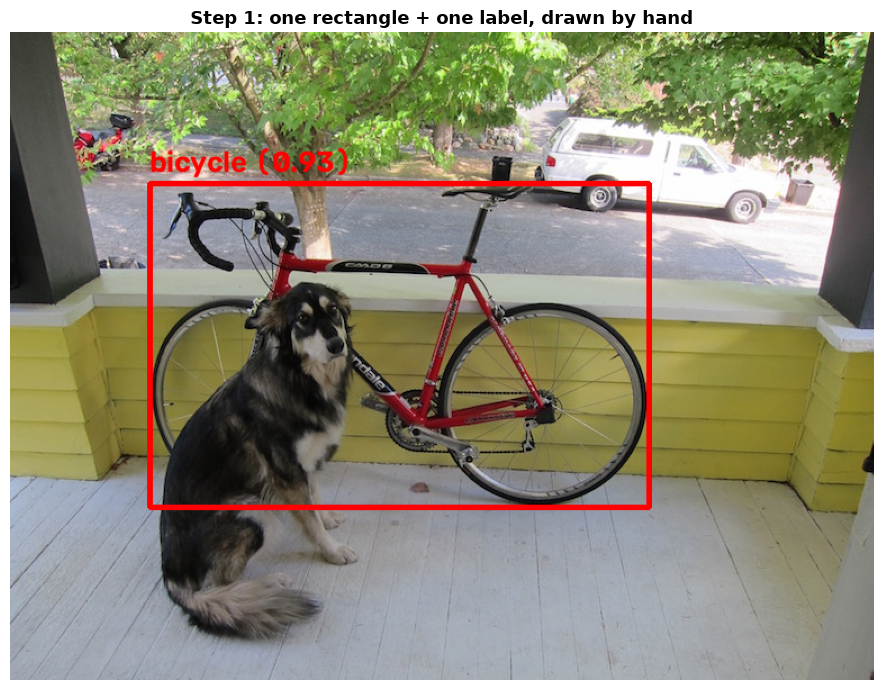

In [20]:
# ALWAYS work on a copy - cv2 drawing functions modify the array in place!
demo = image.copy()

# Pull out detection #0 again
x1, y1, x2, y2 = [int(v) for v in result.boxes.xyxy[0]]
class_name     = result.names[int(result.boxes.cls[0])]
confidence     = float(result.boxes.conf[0])

# 1) The rectangle: top-left corner, bottom-right corner (BGR), thickness
cv2.rectangle(demo, (x1, y1), (x2, y2), (0, 0, 255), 3)

# 2) The text label, placed just above the top-left corner (y1 - 10)
label = f"{class_name} ({confidence:.2f})"
cv2.putText(demo, label, (x1, y1 - 10),
            cv2.FONT_HERSHEY_SIMPLEX,  # font
            0.9,                      # font scale
            (0, 0, 255),              # colour (BGR) - red
            2)                        # thickness

show(demo, "Step 1: one rectangle + one label, drawn by hand")

## Step 2 — a colour per class

If every box is red, overlapping objects are hard to read. Let's give each class ID its own stable colour

In [21]:
# A palette of bright, easy-to-tell-apart colours, written as (R, G, B)
PALETTE_RGB = [
    (255, 112, 31), (255, 178, 29), (207, 210, 49),
    ( 72, 249,  10), ( 26, 147,  52), (  0, 212, 187), (  0, 194, 255),
    (100, 115, 255), (132,  56, 255), (203,  56, 255), (255,  55, 199),
]

def color_for(class_id):
    '''Return a stable BGR colour for a given class ID.'''
    # Modulo means class 0 and class 12 share a colour - fine for 4-6 objects,
    # and it guarantees the SAME class always gets the SAME colour.
    r, g, b = PALETTE_RGB[int(class_id) % len(PALETTE_RGB)]
    return (b, g, r)    # OpenCV wants BGR, not RGB

# Preview a few
for cid in [0, 1, 2, 16]:
    print(f"class {model.names[cid]:<10} -> BGR {color_for(cid)}")

class person     -> BGR (31, 112, 255)
class bicycle    -> BGR (29, 178, 255)
class car        -> BGR (49, 210, 207)
class dog        -> BGR (187, 212, 0)


## Step 3 — loop over all detections

Same five steps for every object:
* 1. Get the coordinates
* 2. Get the class name
* 3. Get the confidence
* 4. Draw the rectangle
* 5. Draw the label

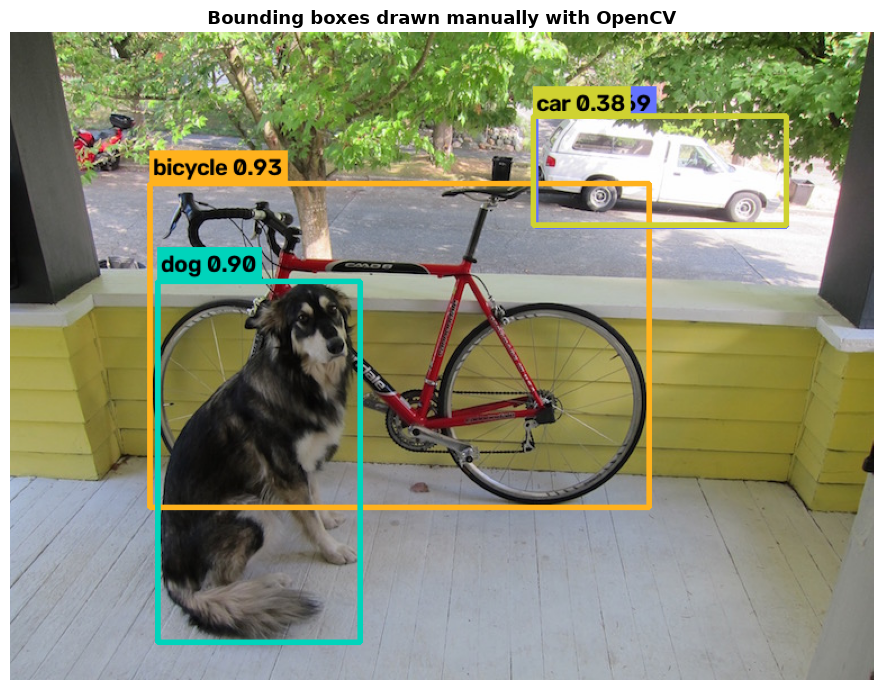

In [23]:
# Start from a clean copy of the original image
annotated_manual = image.copy()

for box in result.boxes:
    # 1) coordinates -> ints, because pixels are whole numbers
    x1, y1, x2, y2 = [int(v) for v in box.xyxy[0]]

    # 2) class name
    class_id = int(box.cls[0])
    class_name = result.names[class_id]

    # 3) confidence
    confidence = float(box.conf[0])

    # a colour for this class
    color = color_for(class_id)

    # 4) the bounding box itself
    cv2.rectangle(annotated_manual, (x1, y1), (x2, y2), color, 3)

    # 5) the label -> "dog 0.91"
    label = f"{class_name} {confidence:.2f}"

    # Measure the text so we can paint a filled background behind it.
    # Without this, light text on a light image is unreadable.
    (text_w, text_h), baseline = cv2.getTextSize(
        label, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2
    )

    # Filled rectangle sitting on top of the box, used as a label background
    cv2.rectangle(annotated_manual,
                  (x1, y1 - text_h - baseline - 6),
                  (x1 + text_w + 6, y1),
                  color, -1)     # -1 thickness = filled

    # The text on top of that background, in black for contrast
    cv2.putText(annotated_manual, label,
                (x1 + 3, y1 - baseline - 3),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 0), 2)

show(annotated_manual, "Bounding boxes drawn manually with OpenCV")


10 · Manual drawing vs. YOLO's built-in .plot()

Now that you know what happens underneath, here is the shortcut you will actually use in real projects — a single method:

Return type: <class 'numpy.ndarray'>
Shape: (576, 768, 3) (same size as the input)


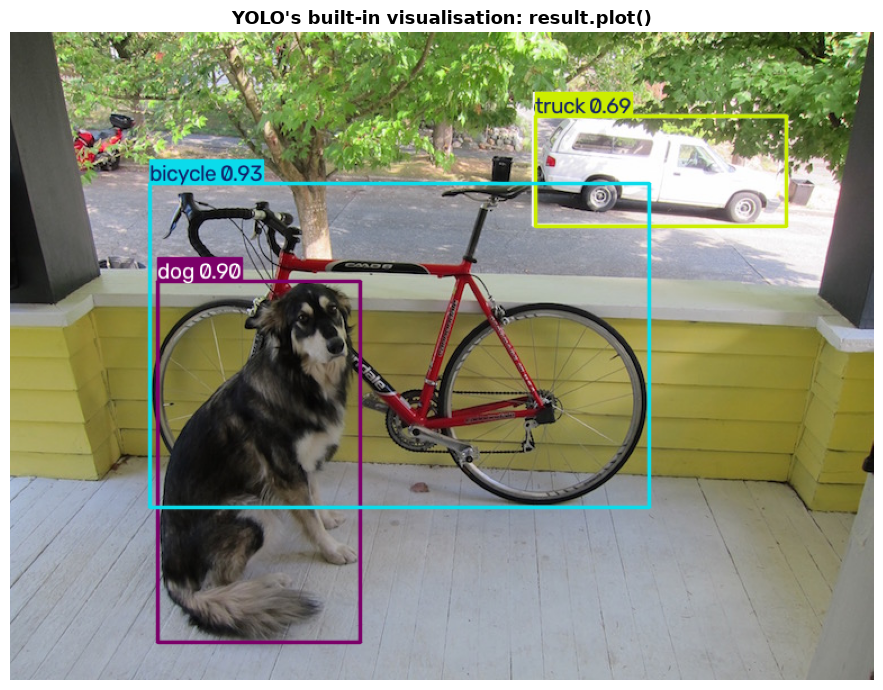

In [24]:
# .plot() returns a BGR annotated image as a NumPy array
annotated_builtin = result.plot()

print("Return type:", type(annotated_builtin))
print("Shape:", annotated_builtin.shape, "(same size as the input)")

show(annotated_builtin, "YOLO's built-in visualisation: result.plot()")

Side by side

(np.float64(-0.5), np.float64(767.5), np.float64(575.5), np.float64(-0.5))

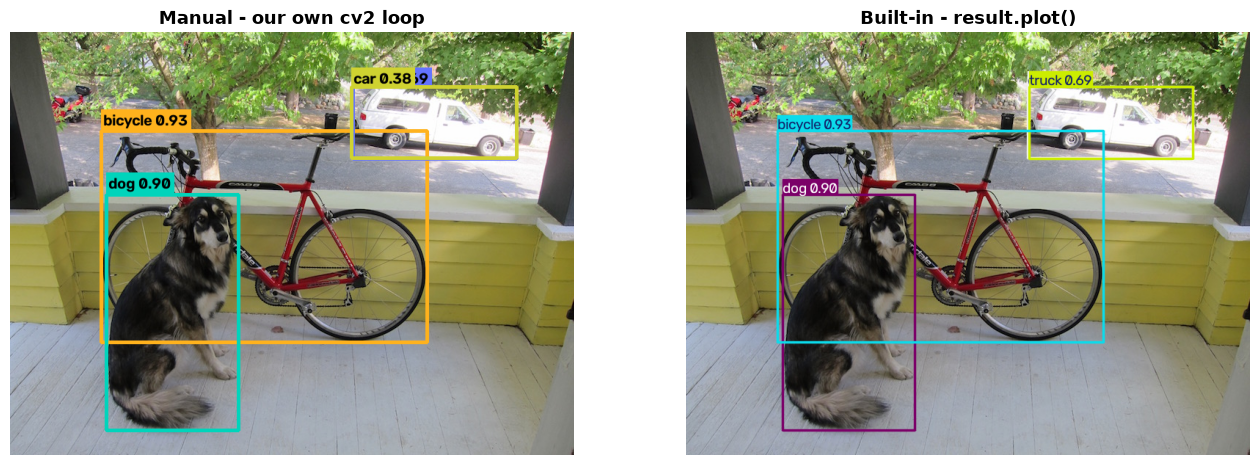

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].imshow(cv2.cvtColor(annotated_manual, cv2.COLOR_BGR2RGB))
axes[0].set_title("Manual - our own cv2 loop", fontsize=13, fontweight="bold")
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(annotated_builtin, cv2.COLOR_BGR2RGB))
axes[1].set_title("Built-in - result.plot()", fontsize=13, fontweight="bold")
axes[1].axis("off")

## 11 · The confidence threshold

In [26]:
def detect_and_count(img, conf):
    '''Run YOLO at a given confidence threshold and report what survived.'''
    res = model(img, conf=conf, verbose=False)[0]
    found = [(res.names[int(b.cls[0])], float(b.conf[0])) for b in res.boxes]
    return res, found

for threshold in [0.05, 0.25, 0.50, 0.80]:
    res, found = detect_and_count(image, threshold)
    print(f"conf = {threshold:.2f} -> {len(found)} detections")
    for name, score in found:
        print(f"    {name:<10} {score:.2f}")
    print()


conf = 0.05 -> 6 detections
    bicycle    0.93
    dog        0.90
    truck      0.69
    car        0.38
    potted plant 0.07
    potted plant 0.06

conf = 0.25 -> 4 detections
    bicycle    0.93
    dog        0.90
    truck      0.69
    car        0.38

conf = 0.50 -> 3 detections
    bicycle    0.93
    dog        0.90
    truck      0.69

conf = 0.80 -> 2 detections
    bicycle    0.93
    dog        0.90




See it, don't just read it

The same image, four thresholds, side by side.

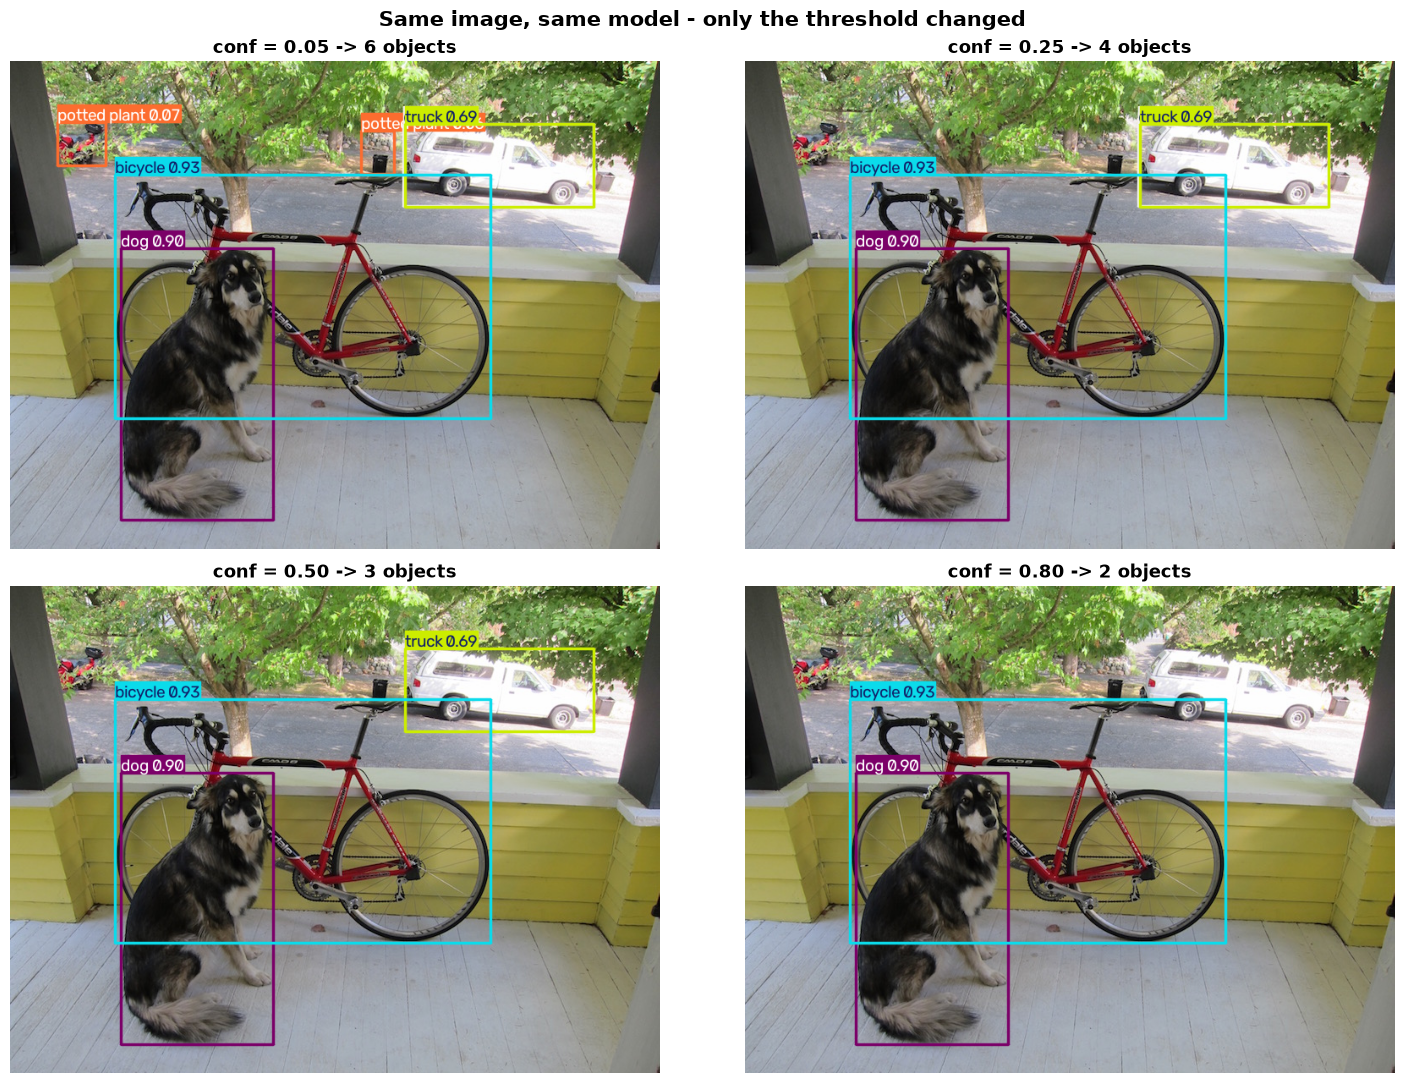

In [27]:
thresholds = [0.05, 0.25, 0.50, 0.80]

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

for ax, threshold in zip(axes.ravel(), thresholds):
    res = model(image, conf=threshold, verbose=False)[0]
    ax.imshow(cv2.cvtColor(res.plot(), cv2.COLOR_BGR2RGB))
    ax.set_title(f"conf = {threshold:.2f} -> {len(res.boxes)} objects",
                 fontsize=13, fontweight="bold")
    ax.axis("off")

plt.suptitle("Same image, same model - only the threshold changed",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()
